
## RISK MANAGEMENT 
MODULE 6 | LESSON 4


---



# **LEARNING THE BAYESIAN NETWORK STRUCTURE AND PARAMETERS FROM DATA**




|  |  |
|:---|:---|
|**Reading Time** |  30 minutes |
|**Prior Knowledge** |  Bayesian network construction  |
|**Keywords** | Structure scoring, K2 Score|   

---

*So far in this module, we have only read about the structure and parameters that together make up a Bayesian network; in this lesson, we actually perform the techniques using the pgmpy library. We see how easy it is now that we know the concepts.*


In [1]:
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
from pgmpy.models import BayesianNetwork

## **1. Recall: A Basic Example**

For this lesson, let's go back to the example of the oil stock price that we modeled in Module 5. Let's assume we were not given the conditional probabilities but instead we were given a set of observations from which we would have to learn the conditional dependence relationships between variables and their condition probabilities ourselves, which we will use K2 to do.
First, let us simulate the data that we know should result in the structure from Module 5. Remember we don't actually have the data that we need, so we need to manufacture it ourselves in order to test the algorithm. As a refresher, here is the structure of the data for the network we constructed:

Figure 1: Oil Stock Price Bayesian Net Example

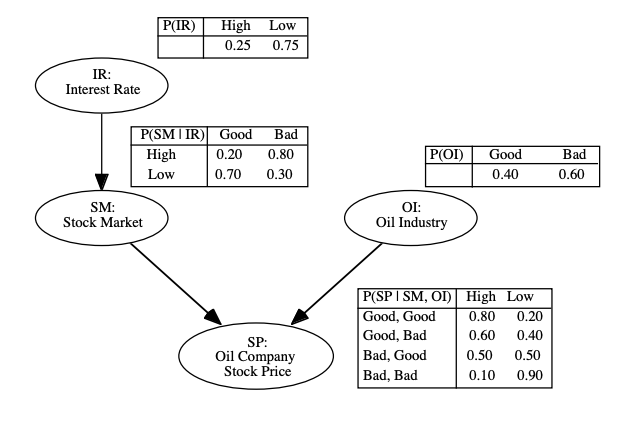

##### Shenoy, Catherine, and Prakash P. Shenoy. "Bayesian Network Models of Portfolio Risk and Return." *Computational Finance*, edited by Yaser S. Abu-Mostafa, Blake LeBaron, Andrew W. Lo, and Andreas S. Weigend, MIT Press, 1999, pp. 87–106.

We will run through the original steps to construct the BN, then simulate data from it for our algorithm to use to "learn" the network. Obviously, we already know the network, so we know the result that the algorithm should return. This is also a review of Lesson 4 from Module 5 regarding how to construct the network in the first place.

### **Step 1: Define the Model Structure**

In [2]:
stock_price_model = BayesianNetwork(
    [
        ("Interest_Rate", "Stock_Market"),
        ("Stock_Market", "Stock_Price"),
        ("Oil_Industry", "Stock_Price"),
    ]
)

### **Step 2: Define the CPDs**

Again, we use the convention that a high value or an increase in the value of a numerical feature is coded as true (or 1), and a low value or decrease as false (or 0). Also, a good market is 1 and a bad market is 0. 

In [3]:
pd_IR = TabularCPD(variable="Interest_Rate", variable_card=2, values=[[0.75], [0.25]])

pd_OI = TabularCPD(variable="Oil_Industry", variable_card=2, values=[[0.60], [0.40]])

cpd_SM = TabularCPD(
    variable="Stock_Market",
    variable_card=2,
    values=[[0.30, 0.80], [0.70, 0.20]],
    evidence=["Interest_Rate"],
    evidence_card=[2],
)

cpd_SP = TabularCPD(
    variable="Stock_Price",
    variable_card=2,
    values=[[0.20, 0.40, 0.50, 0.90], [0.80, 0.60, 0.50, 0.10]],
    evidence=["Oil_Industry", "Stock_Market"],
    evidence_card=[2, 2],
)

### **Step 3: Add the CPDs to the model**

In [4]:
# Associating the parameters with the model structure.
stock_price_model.add_cpds(pd_IR, pd_OI, cpd_SM, cpd_SP)

In [5]:
cpds = stock_price_model.get_cpds()
for cpd in cpds:
    print(cpd)

+------------------+------+
| Interest_Rate(0) | 0.75 |
+------------------+------+
| Interest_Rate(1) | 0.25 |
+------------------+------+
+-----------------+-----+
| Oil_Industry(0) | 0.6 |
+-----------------+-----+
| Oil_Industry(1) | 0.4 |
+-----------------+-----+
+-----------------+------------------+------------------+
| Interest_Rate   | Interest_Rate(0) | Interest_Rate(1) |
+-----------------+------------------+------------------+
| Stock_Market(0) | 0.3              | 0.8              |
+-----------------+------------------+------------------+
| Stock_Market(1) | 0.7              | 0.2              |
+-----------------+------------------+------------------+
+----------------+-----------------+-----+-----------------+
| Oil_Industry   | Oil_Industry(0) | ... | Oil_Industry(1) |
+----------------+-----------------+-----+-----------------+
| Stock_Market   | Stock_Market(0) | ... | Stock_Market(1) |
+----------------+-----------------+-----+-----------------+
| Stock_Price(0) | 

### **Step 4: Test the validity of the model**

.check_model() checks that the sum of the probabilities for each state is equal to 1 within a small tolerance and that the CPDs are consistent.

In [6]:
# Checking if the cpds are valid for the model.
stock_price_model.check_model()

True

As expected (since we did this before), our model is valid. What if it was not? Take the following code for example and try running it:

stock_price_model_1 = BayesianNetwork(
    [
      ("Interest_Rate", "Stock_Market"), 
     ("Stock_Market", "Stock_Price"), 
     ("Oil_Industry", "Stock_Price")
    ]
)

pd_IR = TabularCPD(variable="Interest_Rate", variable_card=2, values=[[0.80], [0.25]])

pd_OI = TabularCPD(variable="Oil_Industry", variable_card=2, values=[[0.60], [0.40]])

cpd_SM = TabularCPD(
    variable="Stock_Market",
    variable_card=2,
    values=[[ 0.30, 0.80], [0.70, 0.20]],
    evidence=["Interest_Rate"],
    evidence_card=[2],
)

cpd_SP = TabularCPD(
    variable="Stock_Price",
    variable_card=2,
    values=[[0.20, 0.40, 0.50, 0.90], [0.80, 0.60, 0.50, 0.10]],
    evidence=["Oil_Industry", "Stock_Market"],
    evidence_card=[2, 2],
)

stock_price_model_1.add_cpds(pd_IR, pd_OI, cpd_SM, cpd_SP)


stock_price_model_1.check_model()

In this case, we get a well-deserved error message, which you will want to see to understand (so run the text as code).<span style='color: transparent; font-size:1%'>All rights reserved WQU WorldQuant University QQQQ</span>


Lastly, we can check that the stock price inference with variable elimination has the same result as before and then feel fairly confident that we have replicated our earlier model.

In [7]:
infer = VariableElimination(stock_price_model)
binary_stock_dist = infer.query(["Stock_Price"])
print(binary_stock_dist)

+----------------+--------------------+
| Stock_Price    |   phi(Stock_Price) |
+================+====================+
| Stock_Price(0) |             0.4810 |
+----------------+--------------------+
| Stock_Price(1) |             0.5190 |
+----------------+--------------------+


## **2. Simulation at Last**

Now we can simulate the data with random draws from the model we constructed. We will use 100,000 for now. W can then attempt to learn the structure of this data and see whether the learned structure matches the structure that we know the data has (because it is the structure from which we generated the data).

In [8]:
sim_data = stock_price_model.simulate(100000)
sim_data

  0%|          | 0/4 [00:00<?, ?it/s]

,Stock_Price,Stock_Market,Oil_Industry,Interest_Rate
0,1,0,1,1
1,1,0,0,1
2,0,1,1,0
3,1,1,0,0
4,0,0,1,0
...,...,...,...,...
99995,1,0,0,0
99996,0,1,1,0
99997,0,1,0,0
99998,0,1,1,0


## 3. **Check the Probabilities and Conditional Probabilities**

Let's check a few probabilities against what we know:

In [9]:
sim_data[sim_data["Interest_Rate"] == 0]["Stock_Price"].count() / 100000

0.75009

Good, this is close to the 75% that we expected.

In [10]:
sim_data[sim_data["Oil_Industry"] == 0]["Stock_Price"].count() / 100000

0.59842

And this is close to the 60% that we want to see. Now what is the conditional probability of the stock market being bad given a low interest rate?

In [11]:
Low_IR_count = sim_data[sim_data["Interest_Rate"] == 0]["Stock_Price"].count()

sim_data[(sim_data["Interest_Rate"] == 0) & (sim_data["Stock_Market"] == 0)][
    "Stock_Price"
].count() / Low_IR_count

0.29931074937674146

30% as predicted by the conditional probability tables (CPDs) in the figures above. 
And what is the conditional probability of the stock market being good given a high interest rate?

In [12]:
High_IR_count = sim_data[sim_data["Interest_Rate"] == 1]["Stock_Price"].count()

sim_data[(sim_data["Interest_Rate"] == 1) & (sim_data["Stock_Market"] == 1)][
    "Stock_Price"
].count() / High_IR_count

0.2000320115241487

This is close enough to the 20% we expected. We could continue to check the conditional probabilities suggested by our simulated data against the conditional probabilities that we intended, but we will let the foregoing suffice.

Now let us see how well the pgmpy library can learn the structure of the data. We start with the `HillClimbSearch` which "estimates the DAG structure that has optimal score, according to the scoring method supplied" ("Hill Climb Search"). Similar to the K2 algorithm, `HillClimbSearch` starts by default with a completely disconnected network ("Hill Climb Search"). However, instead of running through a list of potential parent nodes in the order provided by the user, `HillClimbSearch` tries all permitted permutations up the the number of max iterations specified by the user, and only keeps those parent node permutations that result in local maxima. 

In [13]:
from pgmpy.estimators import BDeuScore, BDsScore, BicScore, HillClimbSearch, K2Score

est = HillClimbSearch(sim_data)

Next, we choose from the list of scoring methods:
*   K2Score
*   BicScore
*   BDeuScore 
*   BDsScore

We will begin with the one we are already familiar with from the last lesson's reading, K2Score. We will note which edges it suggests and compare them to what we know the structure to be: 


In [14]:
K2_best_model = est.estimate(scoring_method=K2Score(sim_data))
sorted(K2_best_model.nodes())
K2_best_model.edges()

  0%|          | 0/1000000 [00:00<?, ?it/s]

OutEdgeView([('Stock_Market', 'Stock_Price'), ('Oil_Industry', 'Stock_Price'), ('Interest_Rate', 'Stock_Market')])

So far so good: The returned directional edges are just as we defined them in Step 1 above. We might as well see how the other scoring methods perform. 

In [15]:
Bic_best_model = est.estimate(scoring_method=BicScore(sim_data))
sorted(Bic_best_model.nodes())
Bic_best_model.edges()

  0%|          | 0/1000000 [00:00<?, ?it/s]

OutEdgeView([('Stock_Market', 'Interest_Rate'), ('Stock_Market', 'Stock_Price'), ('Oil_Industry', 'Stock_Price')])

In [16]:
Bdeu_best_model = est.estimate(scoring_method=BDeuScore(sim_data))
sorted(Bdeu_best_model.nodes())
Bdeu_best_model.edges()

  0%|          | 0/1000000 [00:00<?, ?it/s]

OutEdgeView([('Stock_Market', 'Interest_Rate'), ('Stock_Market', 'Stock_Price'), ('Oil_Industry', 'Stock_Price')])

In [17]:
BDs_best_model = est.estimate(scoring_method=BDsScore(sim_data))
sorted(BDs_best_model.nodes())
BDs_best_model.edges()

  0%|          | 0/1000000 [00:00<?, ?it/s]

OutEdgeView([('Stock_Market', 'Interest_Rate'), ('Stock_Market', 'Stock_Price'), ('Oil_Industry', 'Stock_Price')])

The other three scoring methods correctly learned the edges but got the direction wrong with respect to the `Stock_Market` and `Interest_Rate` variables. Our assumption when constructing this network was informed by domain knowledge according to which interest rates are generally said to directly influence the stock market and not the other way around. Knowing this, we can still use the edges recommended by the other scoring methods and simply modify the direction of the one edge manually.

In [18]:
model_struct = BayesianNetwork(ebunch=K2_best_model.edges())
model_struct.nodes()

NodeView(('Stock_Market', 'Stock_Price', 'Oil_Industry', 'Interest_Rate'))

Now all that is left is to parameterize our structure with CPDs, for which we will use pgmpy's `MaximumLikelihoodEstimator` method. The CPDs are simply populated such that P(\text{data}|\text{model}) is maximized based on the relative frequencies, as you would expect. These values closely mirror the values at the top of this notebook, indicating that our techniques--and the pgmpy library--performed well.

In [19]:
from pgmpy.estimators import MaximumLikelihoodEstimator

# Fitting the model using Maximum Likelihood Estimator
mle = MaximumLikelihoodEstimator(model=model_struct, data=sim_data)

print(mle.estimate_cpd(node="Interest_Rate"))
print(mle.estimate_cpd(node="Stock_Market"))
print(mle.estimate_cpd(node="Oil_Industry"))
print(mle.estimate_cpd(node="Stock_Price"))

+------------------+---------+
| Interest_Rate(0) | 0.75009 |
+------------------+---------+
| Interest_Rate(1) | 0.24991 |
+------------------+---------+
+-----------------+---------------------+--------------------+
| Interest_Rate   | Interest_Rate(0)    | Interest_Rate(1)   |
+-----------------+---------------------+--------------------+
| Stock_Market(0) | 0.29931074937674146 | 0.7999679884758513 |
+-----------------+---------------------+--------------------+
| Stock_Market(1) | 0.7006892506232586  | 0.2000320115241487 |
+-----------------+---------------------+--------------------+
+-----------------+---------+
| Oil_Industry(0) | 0.59842 |
+-----------------+---------+
| Oil_Industry(1) | 0.40158 |
+-----------------+---------+
+----------------+-----+---------------------+
| Oil_Industry   | ... | Oil_Industry(1)     |
+----------------+-----+---------------------+
| Stock_Market   | ... | Stock_Market(1)     |
+----------------+-----+---------------------+
| Stock_Price(0) | 

## **4. Conclusion**

In this notebook, we wanted to practice learning the structure and parameterization for a Bayesian network. In order to do this and have a benchmark with which to compare our results, we simulated data from the oil stock price example that we started in Module 5. In the next module, we look at another use case for Bayesian networks, namely in the context of financial climate risk. We also learn novel ways that climate risk has been  incorporated into credit risk modeling for a bank's mortgage portfolio.

In [20]:
K2_best_model = est.estimate(scoring_method=K2Score(sim_data))
K2_best_model.edges()

  0%|          | 0/1000000 [00:00<?, ?it/s]

OutEdgeView([('Stock_Market', 'Stock_Price'), ('Oil_Industry', 'Stock_Price'), ('Interest_Rate', 'Stock_Market')])

In [21]:
K2_best_model.nodes()

NodeView(('Stock_Price', 'Stock_Market', 'Oil_Industry', 'Interest_Rate'))

**References**

- "Hill Climb Search." *pygmy.org.* https://pgmpy.org/structure_estimator/hill.html#

- Shenoy, Catherine, and Prakash P. Shenoy. "Bayesian Network Models of Portfolio Risk and Return." *Computational Finance*, edited by Yaser S. Abu-Mostafa, Blake LeBaron, Andrew W. Lo, and Andreas S. Weigend, MIT Press, 1999, pp. 87–106.


---
Copyright 2023 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
